# Laboratorio 4 - Análisis de Datos Geoespaciales
## Ejercicios completos

En este notebook se trabaja con imágenes Sentinel-2 para los lagos Atitlán y Amatitlán.

Repo: https://github.com/Ninaswiftie09/Data_Science/tree/Laboratorio4


## 1. Importaciones y configuración


In [1]:
from pathlib import Path
from datetime import timedelta
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import openeo
from tqdm.auto import tqdm

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


# ============================================================
# RUTA DEL PROYECTO
# ============================================================

project_root = Path.cwd()


if project_root.name == "notebooks":
    project_root = project_root.parent


if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


# ============================================================
# RUTAS DE DATOS Y RESULTADOS
# ============================================================

RAW_DATA_DIR = project_root / "data" / "raw"
PROCESSED_DATA_DIR = project_root / "data" / "processed"

DATOS_DIR = RAW_DATA_DIR / "sentinel2"


RESULTADOS_DIR = PROCESSED_DATA_DIR
GRAFICOS_DIR = PROCESSED_DATA_DIR / "figures"

for carpeta in [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    DATOS_DIR,
    GRAFICOS_DIR
]:
    carpeta.mkdir(parents=True, exist_ok=True)


# ============================================================
# CONFIGURACIÓN DEL LAB
# ============================================================

RESOLUCION_METROS = 20


MAX_FECHAS = None

LAGOS = {
    "Atitlán": {
        "bbox": {
            "west": -91.326256,
            "east": -91.07151,
            "south": 14.5948,
            "north": 14.750979
        },
        "fechas": [
            "2025-01-18", "2025-04-13", "2025-05-13", "2025-07-17",
            "2025-11-21", "2025-12-29", "2026-02-12", "2026-03-24",
            "2026-04-13", "2026-04-28", "2026-07-22"
        ]
    },
    "Amatitlán": {
        "bbox": {
            "west": -90.638065,
            "east": -90.512924,
            "south": 14.412347,
            "north": 14.493799
        },
        "fechas": [
            "2025-01-28", "2025-04-15", "2025-04-28", "2025-11-24",
            "2026-01-08", "2026-02-02", "2026-02-07", "2026-03-29",
            "2026-04-13", "2026-04-28", "2026-06-19"
        ]
    }
}

# Bandas mínimas
# NDVI -> B04 y B08
# NDWI -> B03 y B08
# Cianobacteria -> B04, B05, B06 y B08
# SCL -> máscara de nubes
BANDAS = ["B03", "B04", "B05", "B06", "B08", "SCL"]

print("Carpeta del proyecto:", project_root)
print("Datos raster:", DATOS_DIR)
print("Resultados:", RESULTADOS_DIR)
print("Gráficas:", GRAFICOS_DIR)
print("Configuración lista.")


Carpeta del proyecto: c:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science
Datos raster: c:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\raw\sentinel2
Resultados: c:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\processed
Gráficas: c:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\processed\figures
Configuración lista.


## 2. Fechas 



In [2]:
nubosidad = pd.DataFrame([
    # Amatitlán
    ["Amatitlán", "2025-01-28", 0.06, "Sentinel-2B"],
    ["Amatitlán", "2025-04-15", 0.09, "Sentinel-2A"],
    ["Amatitlán", "2025-04-28", 1.03, "Sentinel-2B"],
    ["Amatitlán", "2025-11-24", 0.50, "Sentinel-2B"],
    ["Amatitlán", "2026-01-08", 0.77, "Sentinel-2C"],
    ["Amatitlán", "2026-02-02", 0.39, "Sentinel-2B"],
    ["Amatitlán", "2026-02-07", 0.02, "Sentinel-2C"],
    ["Amatitlán", "2026-03-29", 0.01, "Sentinel-2C"],
    ["Amatitlán", "2026-04-13", 0.09, "Sentinel-2B"],
    ["Amatitlán", "2026-04-28", 4.96, "Sentinel-2C"],
    ["Amatitlán", "2026-06-19", 13.00, "Sentinel-2A"],

    # Atitlán
    ["Atitlán", "2025-01-18", 0.02, "Sentinel-2B"],
    ["Atitlán", "2025-04-13", 0.54, "Sentinel-2C"],
    ["Atitlán", "2025-05-13", 4.37, "Sentinel-2C"],
    ["Atitlán", "2025-07-17", 3.57, "Sentinel-2A"],
    ["Atitlán", "2025-11-21", 3.15, "Sentinel-2A"],
    ["Atitlán", "2025-12-29", 3.17, "Sentinel-2C"],
    ["Atitlán", "2026-02-12", 0.04, "Sentinel-2B"],
    ["Atitlán", "2026-03-24", 3.17, "Sentinel-2B"],
    ["Atitlán", "2026-04-13", 0.01, "Sentinel-2B"],
    ["Atitlán", "2026-04-28", 4.96, "Sentinel-2C"],
    ["Atitlán", "2026-07-22", 4.02, "Sentinel-2B"],
], columns=["lago", "fecha", "nubosidad_pct", "satelite"])

nubosidad["fecha"] = pd.to_datetime(nubosidad["fecha"])
nubosidad


,lago,fecha,nubosidad_pct,satelite
0,Amatitlán,2025-01-28,0.06,Sentinel-2B
1,Amatitlán,2025-04-15,0.09,Sentinel-2A
2,Amatitlán,2025-04-28,1.03,Sentinel-2B
3,Amatitlán,2025-11-24,0.50,Sentinel-2B
4,Amatitlán,2026-01-08,0.77,Sentinel-2C
5,Amatitlán,2026-02-02,0.39,Sentinel-2B
6,Amatitlán,2026-02-07,0.02,Sentinel-2C
7,Amatitlán,2026-03-29,0.01,Sentinel-2C
8,Amatitlán,2026-04-13,0.09,Sentinel-2B
9,Amatitlán,2026-04-28,4.96,Sentinel-2C


# Ejercicio 1. Conexión con la API de Sentinel-2

Se usa openEO con Copernicus Data Space Ecosystem.


In [3]:
CONEXION_URL = "https://openeo.dataspace.copernicus.eu"

conn = openeo.connect(CONEXION_URL)
conn.authenticate_oidc()

print("Conexión realizada correctamente.")
print("Backend:", CONEXION_URL)


Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=IKCQ-IASI 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.
Conexión realizada correctamente.
Backend: https://openeo.dataspace.copernicus.eu


### Revisión de la colección



In [4]:
coleccion = conn.describe_collection("SENTINEL2_L2A")

print("Colección:", coleccion.get("id"))
print("Título:", coleccion.get("title", "Sin título"))
print("Bandas que vamos a usar:", BANDAS)


Colección: SENTINEL2_L2A
Título: Sentinel-2 L2A
Bandas que vamos a usar: ['B03', 'B04', 'B05', 'B06', 'B08', 'SCL']


# Ejercicio 2. Obtención de datos raster

No se descargan escenas completas. Cada descarga queda recortada al cuadro del lago y solo contiene las bandas necesarias.

Para no repetir descargas, si el archivo ya existe se reutiliza.

In [5]:
def nombre_seguro(texto):
    return (
        texto.lower()
        .replace("á", "a")
        .replace("é", "e")
        .replace("í", "i")
        .replace("ó", "o")
        .replace("ú", "u")
        .replace(" ", "_")
    )


def descargar_bandas_fecha(conn, lago, bbox, fecha, resolucion=20):
    slug = nombre_seguro(lago)
    salida = DATOS_DIR / f"{slug}_{fecha}.tif"

    if salida.exists():
        return salida

    fecha_inicio = pd.Timestamp(fecha)
    fecha_fin = (fecha_inicio + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

    cubo = conn.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=bbox,
        temporal_extent=[fecha, fecha_fin],
        bands=BANDAS
    )

    cubo = cubo.resample_spatial(resolution=resolucion)

    cubo = cubo.max_time()

    cubo.download(str(salida), format="GTiff")
    return salida


print("Función de descarga lista.")


Función de descarga lista.


### Prueba de una sola fecha


In [6]:
lago_prueba = "Atitlán"
fecha_prueba = LAGOS[lago_prueba]["fechas"][0]

archivo_prueba = descargar_bandas_fecha(
    conn,
    lago_prueba,
    LAGOS[lago_prueba]["bbox"],
    fecha_prueba,
    resolucion=RESOLUCION_METROS
)

print("Archivo de prueba:", archivo_prueba)


Archivo de prueba: c:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\raw\sentinel2\atitlan_2025-01-18.tif


# Ejercicio 3. Cálculo de NDVI, NDWI e índice de cianobacteria

Se calculan tres índices:

- NDVI usa B04 y B08.
- NDWI usa B03 y B08.
- Cianobacteria usa el Maximum Peak Height Bloom Index de CyanoLakes. El índice toma el máximo entre MCI y FAI usando B04, B05, B06 y B08.

También se usa la banda SCL para quitar nubes y sombras. NDWI se usa para quedarnos principalmente con píxeles de agua.

Un valor de cianobacteria más alto indica una señal espectral más fuerte asociada a floraciones.


In [7]:
CLASES_SCL_NO_VALIDAS = {1, 3, 8, 9, 10, 11}


def division_segura(num, den):
    salida = np.full_like(num, np.nan, dtype="float32")
    valido = np.abs(den) > 1e-8
    salida[valido] = num[valido] / den[valido]
    return salida


def leer_y_calcular_indices(ruta_tif):
    with rasterio.open(ruta_tif) as src:
        data = src.read().astype("float32")
        perfil = src.profile.copy()
        transform = src.transform
        crs = src.crs
        nodata = src.nodata

    if data.shape[0] != len(BANDAS):
        raise ValueError(
            f"Se esperaban {len(BANDAS)} bandas, pero el archivo tiene {data.shape[0]}."
        )

    valores = {banda: data[i] for i, banda in enumerate(BANDAS)}

    p99_rojo = np.nanpercentile(valores["B04"], 99)
    escala = 0.0001 if p99_rojo > 2 else 1.0

    for banda in ["B03", "B04", "B05", "B06", "B08"]:
        valores[banda] = valores[banda] * escala

    b03 = valores["B03"]
    b04 = valores["B04"]
    b05 = valores["B05"]
    b06 = valores["B06"]
    b08 = valores["B08"]
    scl = valores["SCL"]

    ndvi = division_segura(b08 - b04, b08 + b04)
    ndwi = division_segura(b03 - b08, b03 + b08)

    # Maximum Peak Height Bloom Index:
    # MCI usa 665, 705 y 740 nm
    mci = b05 - b04 - (b06 - b04) * ((705 - 665) / (740 - 665))

    # FAI usa 665, 740 y 842 nm
    fai = b06 - b04 - (b08 - b04) * ((740 - 665) / (842 - 665))

    cyano = np.maximum(mci, fai)

    # Máscara básica de calidad.
    valido = np.isfinite(b03) & np.isfinite(b04) & np.isfinite(b08)
    valido &= (b03 > 0) & (b04 > 0) & (b08 > 0)

    # Quitar nubes, sombras, cirrus, nieve y píxeles defectuosos.
    mascara_scl = ~np.isin(scl.astype("int16"), list(CLASES_SCL_NO_VALIDAS))
    valido &= mascara_scl

    mascara_agua = ndwi > 0
    valido &= mascara_agua

    ndvi_mask = np.where(valido, ndvi, np.nan)
    ndwi_mask = np.where(valido, ndwi, np.nan)
    cyano_mask = np.where(valido, cyano, np.nan)

    return {
        "ndvi": ndvi_mask,
        "ndwi": ndwi_mask,
        "cyano": cyano_mask,
        "valido": valido,
        "transform": transform,
        "crs": crs,
        "perfil": perfil
    }


indices_prueba = leer_y_calcular_indices(archivo_prueba)

print("NDVI promedio:", np.nanmean(indices_prueba["ndvi"]))
print("NDWI promedio:", np.nanmean(indices_prueba["ndwi"]))
print("Cianobacteria promedio:", np.nanmean(indices_prueba["cyano"]))
print("Píxeles válidos de agua:", np.sum(indices_prueba["valido"]))


NDVI promedio: 0.3380567
NDWI promedio: 0.7476418
Cianobacteria promedio: 6.738843e-05
Píxeles válidos de agua: 135176


## Visualización rápida de la fecha de prueba


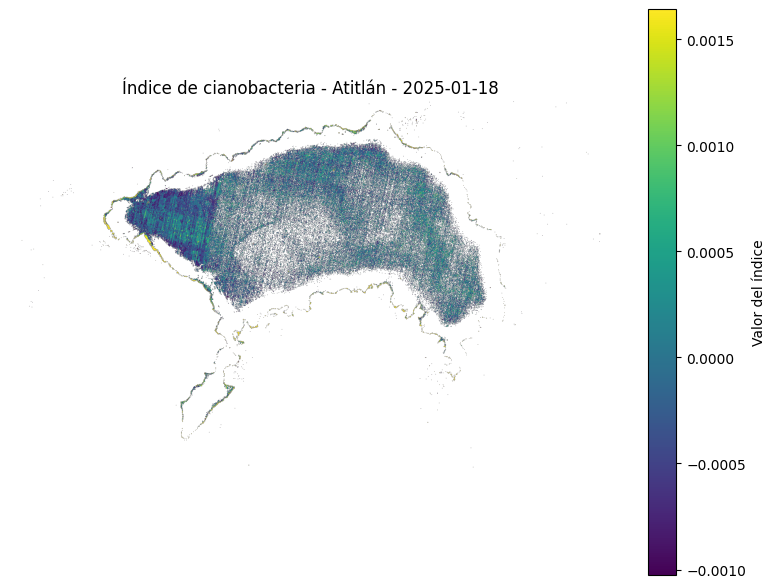

In [8]:
def mostrar_mapa(matriz, titulo, nombre_archivo, percentiles=(2, 98)):
    valores = matriz[np.isfinite(matriz)]

    if valores.size == 0:
        print(f"No hay valores válidos para: {titulo}")
        return

    vmin, vmax = np.nanpercentile(valores, percentiles)

    plt.figure(figsize=(8, 6))
    plt.imshow(matriz, vmin=vmin, vmax=vmax)
    plt.colorbar(label="Valor del índice")
    plt.title(titulo)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(GRAFICOS_DIR / nombre_archivo, dpi=180, bbox_inches="tight")
    plt.show()


mostrar_mapa(
    indices_prueba["cyano"],
    f"Índice de cianobacteria - {lago_prueba} - {fecha_prueba}",
    f"cyano_prueba_{nombre_seguro(lago_prueba)}_{fecha_prueba}.png"
)


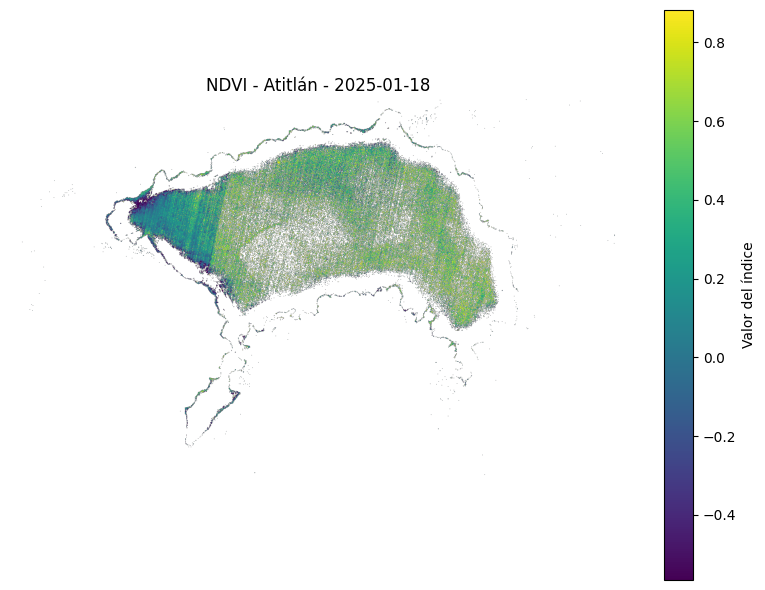

In [9]:
mostrar_mapa(
    indices_prueba["ndvi"],
    f"NDVI - {lago_prueba} - {fecha_prueba}",
    f"ndvi_prueba_{nombre_seguro(lago_prueba)}_{fecha_prueba}.png"
)


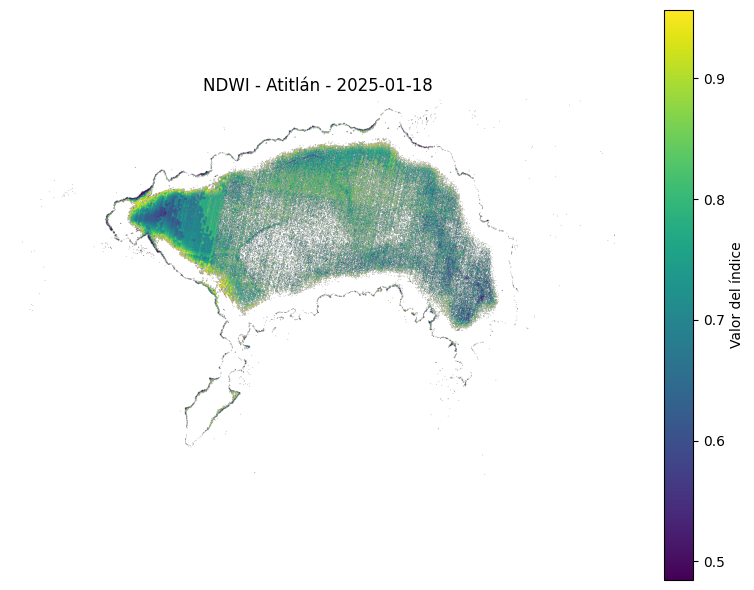

In [10]:
mostrar_mapa(
    indices_prueba["ndwi"],
    f"NDWI - {lago_prueba} - {fecha_prueba}",
    f"ndwi_prueba_{nombre_seguro(lago_prueba)}_{fecha_prueba}.png"
)


# Procesamiento de todas las fechas

Esta celda descarga cada fecha, calcula los índices y guarda una tabla con los promedios.

Si una fecha ya fue descargada, no se vuelve a bajar.

In [11]:
registros = []

for lago, info in LAGOS.items():
    fechas = info["fechas"]
    if MAX_FECHAS is not None:
        fechas = fechas[:MAX_FECHAS]

    print(f"\nProcesando {lago}...")

    for fecha in tqdm(fechas):
        try:
            ruta = descargar_bandas_fecha(
                conn,
                lago,
                info["bbox"],
                fecha,
                resolucion=RESOLUCION_METROS
            )

            indices = leer_y_calcular_indices(ruta)

            cyano = indices["cyano"]
            ndvi = indices["ndvi"]
            ndwi = indices["ndwi"]

            validos_cyano = cyano[np.isfinite(cyano)]

            porcentaje_alto = (
                np.mean(validos_cyano > 0.05) * 100
                if validos_cyano.size > 0 else np.nan
            )

            registros.append({
                "lago": lago,
                "fecha": pd.Timestamp(fecha),
                "cyano_promedio": np.nanmean(cyano),
                "cyano_mediana": np.nanmedian(cyano),
                "ndvi_promedio": np.nanmean(ndvi),
                "ndwi_promedio": np.nanmean(ndwi),
                "porcentaje_cyano_alto": porcentaje_alto,
                "pixeles_validos": np.sum(np.isfinite(cyano)),
                "archivo": str(ruta)
            })

        except Exception as e:
            print(f"Error en {lago} - {fecha}: {e}")

resultados = pd.DataFrame(registros).sort_values(["lago", "fecha"]).reset_index(drop=True)

ruta_csv = RESULTADOS_DIR / "resumen_indices.csv"

resultados_exportar = resultados.copy()
resultados_exportar["archivo"] = resultados_exportar["archivo"].apply(
    lambda ruta: str(Path(ruta).relative_to(project_root))
)

resultados_exportar.to_csv(ruta_csv, index=False)

print("\nResultados guardados en:", ruta_csv)
resultados



Procesando Atitlán...


  0%|          | 0/11 [00:00<?, ?it/s]


Procesando Amatitlán...


  0%|          | 0/11 [00:00<?, ?it/s]


Resultados guardados en: c:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\processed\resumen_indices.csv


,lago,fecha,cyano_promedio,cyano_mediana,ndvi_promedio,ndwi_promedio,porcentaje_cyano_alto,pixeles_validos,archivo
0,Amatitlán,2025-01-28,0.009987,0.009693,-0.344373,0.549045,1.233020,38280,c:\Users\ninan\OneDrive\Documentos\Escritorio\...
1,Amatitlán,2025-04-15,0.015247,0.013170,-0.094094,0.278861,1.084117,38280,c:\Users\ninan\OneDrive\Documentos\Escritorio\...
2,Amatitlán,2025-04-28,0.018849,0.016313,-0.066454,0.280437,1.078384,37278,c:\Users\ninan\OneDrive\Documentos\Escritorio\...
3,Amatitlán,2025-11-24,0.009833,0.008480,-0.360986,0.498736,1.477120,38047,c:\Users\ninan\OneDrive\Documentos\Escritorio\...
4,Amatitlán,2026-01-08,0.011408,0.010993,-0.129435,0.385961,1.261281,35678,c:\Users\ninan\OneDrive\Documentos\Escritorio\...
5,Amatitlán,2026-02-02,0.006541,0.006453,-0.069378,0.179666,0.884630,35269,c:\Users\ninan\OneDrive\Documentos\Escritorio\...
6,Amatitlán,2026-02-07,0.006933,0.007007,-0.207194,0.390761,1.092682,35692,c:\Users\ninan\OneDrive\Documentos\Escritorio\...
7,Amatitlán,2026-03-29,0.024226,0.023780,-0.077985,0.304230,4.118759,39138,c:\Users\ninan\OneDrive\Documentos\Escritorio\...
8,Amatitlán,2026-04-13,0.034218,0.036353,-0.031532,0.272118,1.680672,39746,c:\Users\ninan\OneDrive\Documentos\Escritorio\...
9,Amatitlán,2026-04-28,0.025787,0.019370,-0.050175,0.332712,2.118047,31208,c:\Users\ninan\OneDrive\Documentos\Escritorio\...


# Ejercicio 4. Análisis temporal

Primero se grafica el promedio del índice de cianobacteria por fecha para cada lago. Así se pueden identificar picos y cambios durante el período.

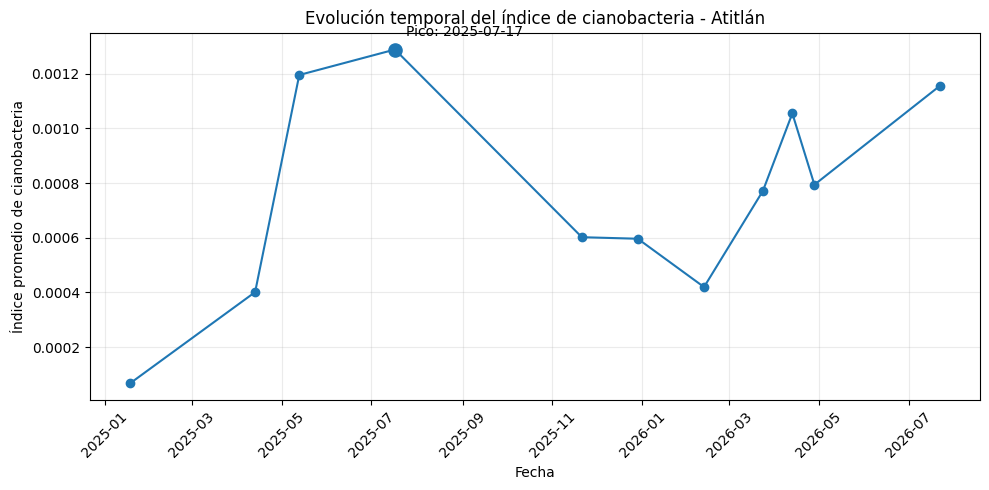

In [12]:
def grafica_temporal_lago(df, lago):
    datos = df[df["lago"] == lago].sort_values("fecha").copy()

    if datos.empty:
        print(f"No hay datos para {lago}.")
        return

    pico = datos.loc[datos["cyano_promedio"].idxmax()]

    plt.figure(figsize=(10, 5))
    plt.plot(datos["fecha"], datos["cyano_promedio"], marker="o")
    plt.scatter([pico["fecha"]], [pico["cyano_promedio"]], s=90)
    plt.annotate(
        f"Pico: {pico['fecha'].date()}",
        (pico["fecha"], pico["cyano_promedio"]),
        xytext=(8, 10),
        textcoords="offset points"
    )
    plt.title(f"Evolución temporal del índice de cianobacteria - {lago}")
    plt.xlabel("Fecha")
    plt.ylabel("Índice promedio de cianobacteria")
    plt.grid(alpha=0.25)
    plt.xticks(rotation=45)
    plt.tight_layout()

    nombre = f"serie_temporal_{nombre_seguro(lago)}.png"
    plt.savefig(GRAFICOS_DIR / nombre, dpi=180, bbox_inches="tight")
    plt.show()


grafica_temporal_lago(resultados, "Atitlán")


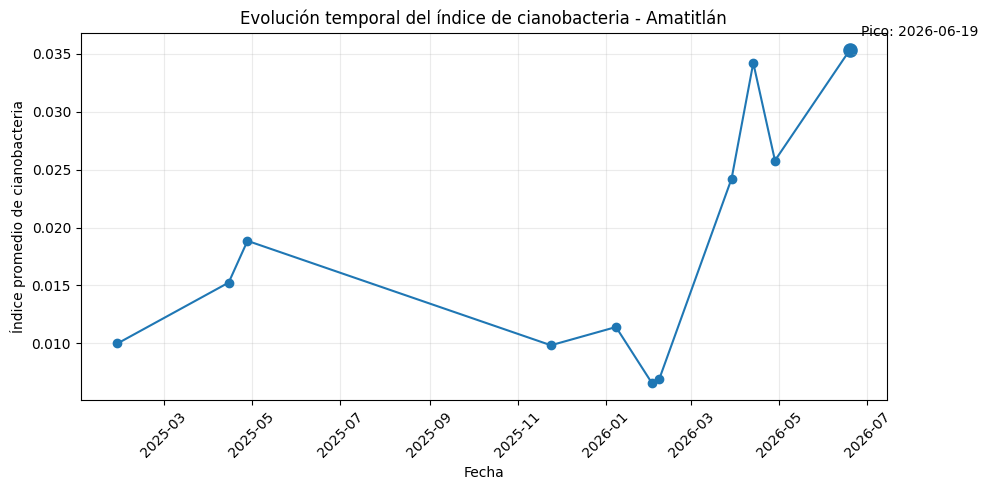

In [13]:
grafica_temporal_lago(resultados, "Amatitlán")


## Comparación visual de ambos lagos

Esta gráfica no sustituye las gráficas individuales, pero ayuda a ver rápidamente cuál lago tiene valores mayores en las fechas estudiadas.

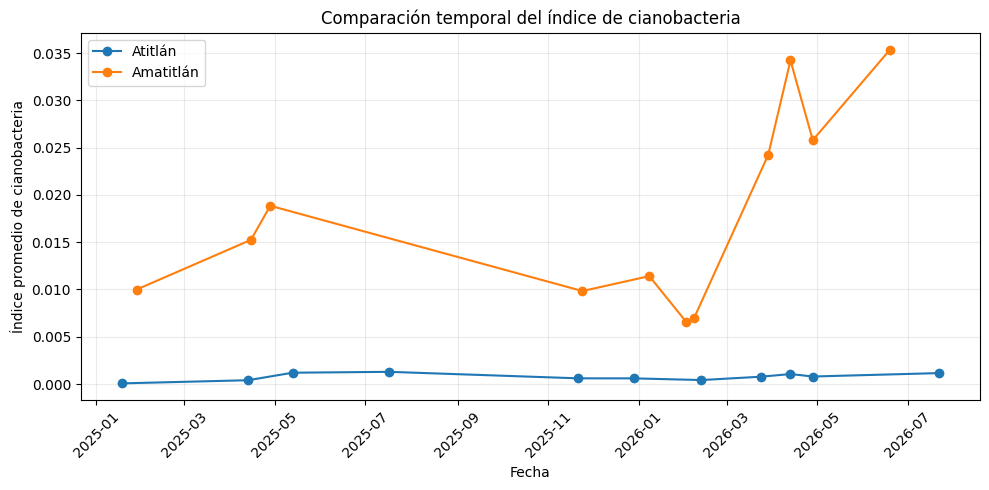

In [14]:
plt.figure(figsize=(10, 5))

for lago in ["Atitlán", "Amatitlán"]:
    datos = resultados[resultados["lago"] == lago].sort_values("fecha")
    if not datos.empty:
        plt.plot(datos["fecha"], datos["cyano_promedio"], marker="o", label=lago)

plt.title("Comparación temporal del índice de cianobacteria")
plt.xlabel("Fecha")
plt.ylabel("Índice promedio de cianobacteria")
plt.legend()
plt.grid(alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(GRAFICOS_DIR / "comparacion_temporal_lagos.png", dpi=180, bbox_inches="tight")
plt.show()


## Resumen automático de hallazgos

El siguiente bloque genera un análisis corto usando los resultados reales. No inventa fechas ni picos: los toma directamente de la tabla.

In [15]:
def analizar_temporal(df):
    textos = []

    for lago in ["Atitlán", "Amatitlán"]:
        datos = df[df["lago"] == lago].dropna(subset=["cyano_promedio"]).sort_values("fecha").copy()

        if len(datos) < 2:
            textos.append(f"{lago}: no hay suficientes datos para analizar la tendencia.")
            continue

        pico = datos.loc[datos["cyano_promedio"].idxmax()]
        minimo = datos.loc[datos["cyano_promedio"].idxmin()]

        dias = (datos["fecha"] - datos["fecha"].min()).dt.days.to_numpy(dtype=float)
        valores = datos["cyano_promedio"].to_numpy(dtype=float)

        pendiente = np.polyfit(dias, valores, 1)[0] if np.ptp(dias) > 0 else 0.0
        cambio_estimado = pendiente * np.ptp(dias)
        rango = np.nanmax(valores) - np.nanmin(valores)

        if rango == 0 or abs(cambio_estimado) < 0.15 * rango:
            tendencia = "no muestra una tendencia clara y más bien fluctúa entre fechas"
        elif cambio_estimado > 0:
            tendencia = "muestra una tendencia general hacia valores más altos"
        else:
            tendencia = "muestra una tendencia general hacia valores más bajos"

        texto = (
            f"{lago}: el valor promedio más alto aparece el {pico['fecha'].date()} "
            f"con {pico['cyano_promedio']:.5f}. El valor más bajo aparece el "
            f"{minimo['fecha'].date()} con {minimo['cyano_promedio']:.5f}. "
            f"En general, la serie {tendencia}. "
            f"El porcentaje de agua con valores altos en la fecha del pico fue de "
            f"{pico['porcentaje_cyano_alto']:.2f}%."
        )
        textos.append(texto)

    return textos


resumen_textual = analizar_temporal(resultados)

for texto in resumen_textual:
    print("- " + texto)


- Atitlán: el valor promedio más alto aparece el 2025-07-17 con 0.00129. El valor más bajo aparece el 2025-01-18 con 0.00007. En general, la serie muestra una tendencia general hacia valores más altos. El porcentaje de agua con valores altos en la fecha del pico fue de 0.15%.
- Amatitlán: el valor promedio más alto aparece el 2026-06-19 con 0.03537. El valor más bajo aparece el 2026-02-02 con 0.00654. En general, la serie muestra una tendencia general hacia valores más altos. El porcentaje de agua con valores altos en la fecha del pico fue de 9.26%.


### Interpretación ambiental

Los cambios entre fechas pueden estar relacionados con factores como temperatura, nutrientes disponibles, lluvia y escorrentía, circulación del agua o períodos de estancamiento.

Aun así, con las imágenes satelitales solas no se puede afirmar cuál fue la causa exacta de un pico. Lo que sí se puede hacer es detectar cuándo la señal aumenta, dónde aparece y qué tan fuerte es el cambio entre fechas.

# Mapas de las fechas con mayor promedio


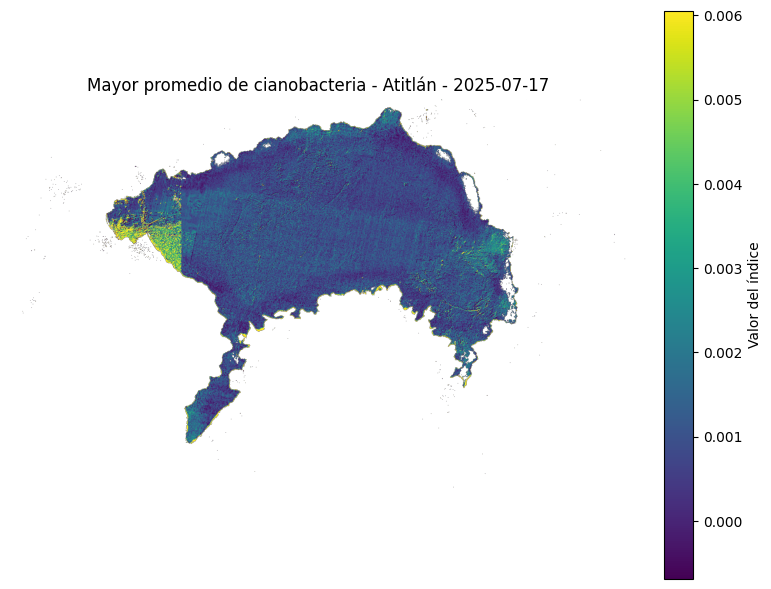

In [16]:
def mapa_fecha_pico(df, lago):
    datos = df[df["lago"] == lago].dropna(subset=["cyano_promedio"])
    if datos.empty:
        print(f"No hay datos para {lago}.")
        return

    fila = datos.loc[datos["cyano_promedio"].idxmax()]
    indices = leer_y_calcular_indices(fila["archivo"])

    mostrar_mapa(
        indices["cyano"],
        f"Mayor promedio de cianobacteria - {lago} - {fila['fecha'].date()}",
        f"mapa_pico_cyano_{nombre_seguro(lago)}.png"
    )


mapa_fecha_pico(resultados, "Atitlán")


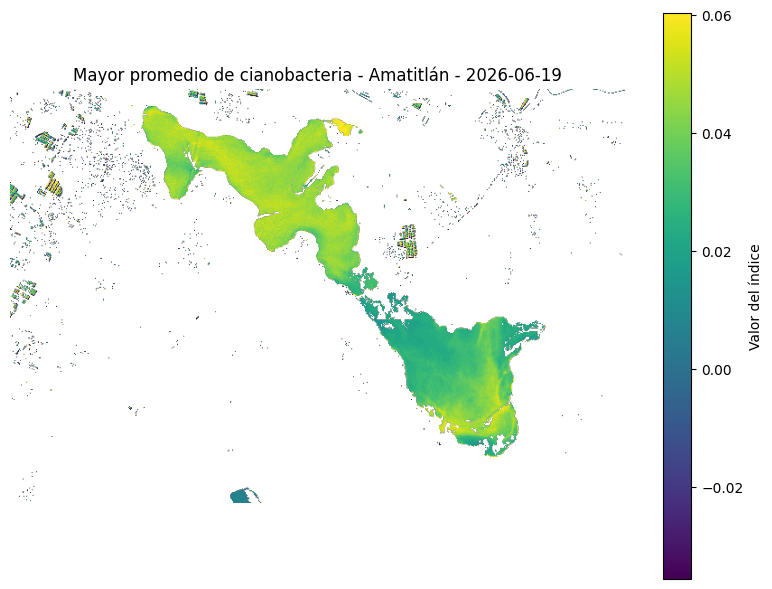

In [17]:
mapa_fecha_pico(resultados, "Amatitlán")


# Tabla 


In [18]:
tabla_avance = resultados[
    [
        "lago",
        "fecha",
        "cyano_promedio",
        "cyano_mediana",
        "ndvi_promedio",
        "ndwi_promedio",
        "porcentaje_cyano_alto",
        "pixeles_validos"
    ]
].copy()

tabla_avance["fecha"] = tabla_avance["fecha"].dt.strftime("%Y-%m-%d")
tabla_avance


,lago,fecha,cyano_promedio,cyano_mediana,ndvi_promedio,ndwi_promedio,porcentaje_cyano_alto,pixeles_validos
0,Amatitlán,2025-01-28,0.009987,0.009693,-0.344373,0.549045,1.233020,38280
1,Amatitlán,2025-04-15,0.015247,0.013170,-0.094094,0.278861,1.084117,38280
2,Amatitlán,2025-04-28,0.018849,0.016313,-0.066454,0.280437,1.078384,37278
3,Amatitlán,2025-11-24,0.009833,0.008480,-0.360986,0.498736,1.477120,38047
4,Amatitlán,2026-01-08,0.011408,0.010993,-0.129435,0.385961,1.261281,35678
5,Amatitlán,2026-02-02,0.006541,0.006453,-0.069378,0.179666,0.884630,35269
6,Amatitlán,2026-02-07,0.006933,0.007007,-0.207194,0.390761,1.092682,35692
7,Amatitlán,2026-03-29,0.024226,0.023780,-0.077985,0.304230,4.118759,39138
8,Amatitlán,2026-04-13,0.034218,0.036353,-0.031532,0.272118,1.680672,39746
9,Amatitlán,2026-04-28,0.025787,0.019370,-0.050175,0.332712,2.118047,31208


# Ejercicio 5. Análisis espacial

En esta parte se compara cómo cambia la cianobacteria dentro de cada lago entre fechas.

Se usan las fechas con menor y mayor promedio para que el cambio sea más fácil de ver. También se calcula cuántas veces aparecen valores altos en las mismas zonas.


In [19]:
def mapa_comparativo_fechas(df, lago):
    datos = df[df["lago"] == lago].dropna(subset=["cyano_promedio"]).copy()

    fila_min = datos.loc[datos["cyano_promedio"].idxmin()]
    fila_max = datos.loc[datos["cyano_promedio"].idxmax()]

    indice_min = leer_y_calcular_indices(fila_min["archivo"])["cyano"]
    indice_max = leer_y_calcular_indices(fila_max["archivo"])["cyano"]

    valores = np.concatenate([
        indice_min[np.isfinite(indice_min)],
        indice_max[np.isfinite(indice_max)]
    ])

    vmin, vmax = np.nanpercentile(valores, [2, 98])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    imagen1 = axes[0].imshow(indice_min, vmin=vmin, vmax=vmax)
    axes[0].set_title(f"{fila_min['fecha'].date()} - menor promedio")
    axes[0].axis("off")

    axes[1].imshow(indice_max, vmin=vmin, vmax=vmax)
    axes[1].set_title(f"{fila_max['fecha'].date()} - mayor promedio")
    axes[1].axis("off")

    fig.colorbar(imagen1, ax=axes.ravel().tolist(), label="Bloom Index", shrink=0.8)
    fig.suptitle(f"Comparación espacial de cianobacteria - {lago}")
    salida = GRAFICOS_DIR / f"comparacion_espacial_{nombre_seguro(lago)}.png"
    plt.savefig(salida, dpi=180, bbox_inches="tight")
    plt.show()

    return fila_min, fila_max


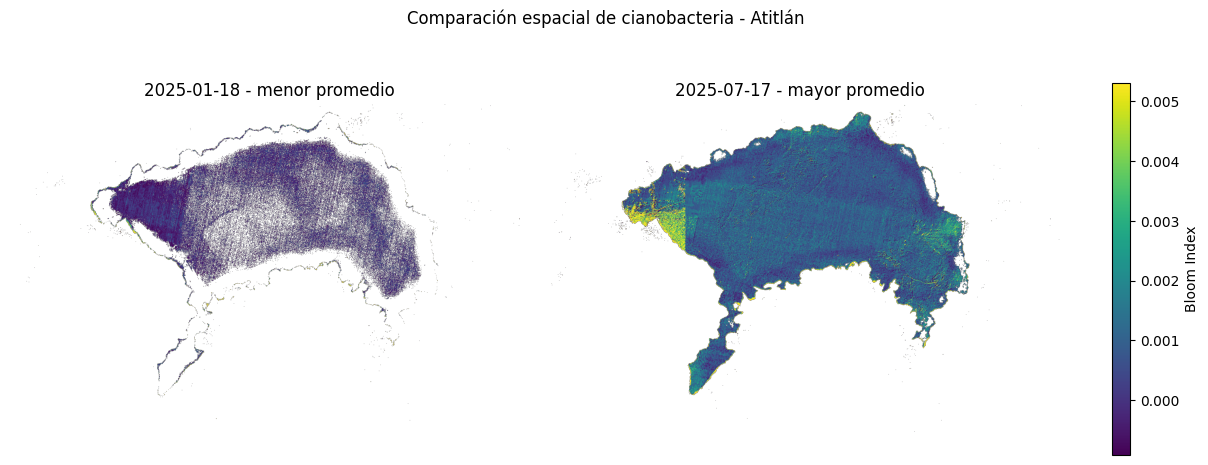

In [20]:
min_atitlan, max_atitlan = mapa_comparativo_fechas(resultados, "Atitlán")


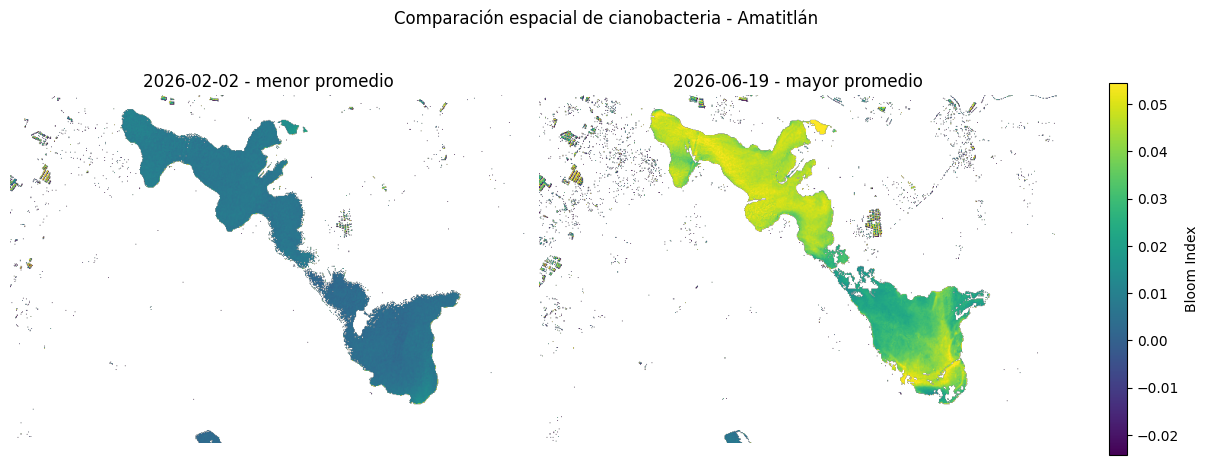

In [21]:
min_amatitlan, max_amatitlan = mapa_comparativo_fechas(resultados, "Amatitlán")


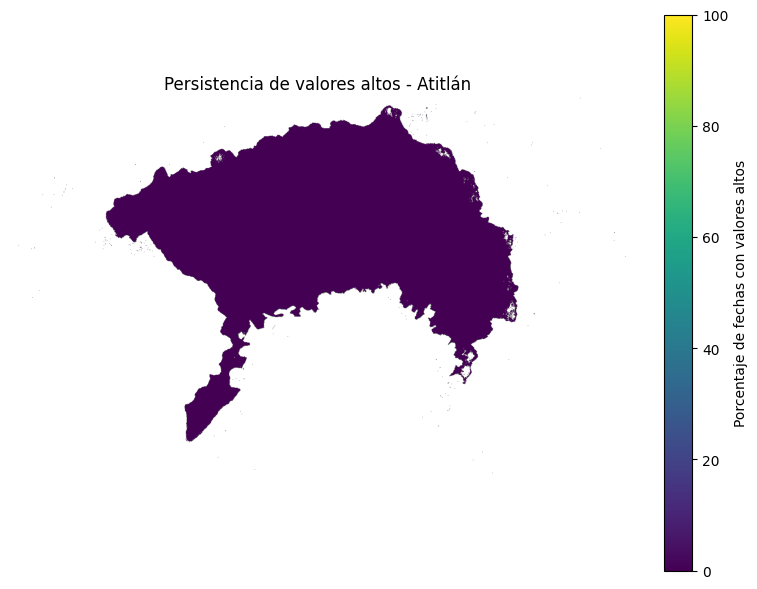

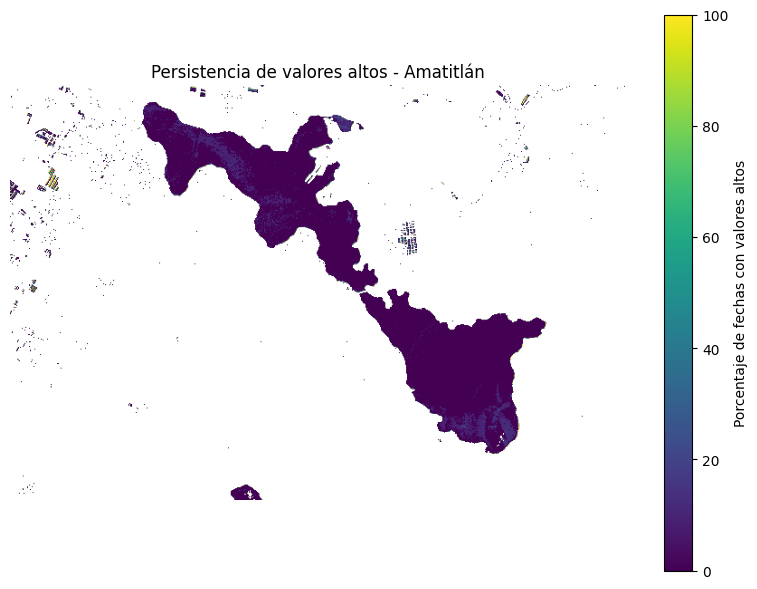

,lago,pixeles_persistentes,zona_principal,max_persistencia
0,Atitlán,441,sureste,100.0
1,Amatitlán,620,noroeste,100.0


In [22]:
def calcular_persistencia(df, lago, umbral=0.05):
    datos = df[df["lago"] == lago].sort_values("fecha")

    conteo_alto = None
    conteo_valido = None

    for _, fila in datos.iterrows():
        indices = leer_y_calcular_indices(fila["archivo"])
        cyano = indices["cyano"]

        valido = np.isfinite(cyano)
        alto = valido & (cyano > umbral)

        if conteo_alto is None:
            conteo_alto = np.zeros_like(cyano, dtype="int16")
            conteo_valido = np.zeros_like(cyano, dtype="int16")

        conteo_alto += alto.astype("int16")
        conteo_valido += valido.astype("int16")

    persistencia = np.full_like(conteo_alto, np.nan, dtype="float32")
    suficiente = conteo_valido >= 6
    persistencia[suficiente] = (
        conteo_alto[suficiente] / conteo_valido[suficiente] * 100
    )

    persistente = suficiente & (conteo_alto >= 3)

    alto, ancho = persistente.shape

    zonas = {
        "noroeste": int(persistente[:alto // 2, :ancho // 2].sum()),
        "noreste": int(persistente[:alto // 2, ancho // 2:].sum()),
        "suroeste": int(persistente[alto // 2:, :ancho // 2].sum()),
        "sureste": int(persistente[alto // 2:, ancho // 2:].sum())
    }

    zona_principal = max(zonas, key=zonas.get)

    plt.figure(figsize=(8, 6))
    imagen = plt.imshow(persistencia, vmin=0, vmax=100)
    plt.colorbar(imagen, label="Porcentaje de fechas con valores altos")
    plt.title(f"Persistencia de valores altos - {lago}")
    plt.axis("off")
    plt.tight_layout()

    salida = GRAFICOS_DIR / f"persistencia_cyano_{nombre_seguro(lago)}.png"
    plt.savefig(salida, dpi=180, bbox_inches="tight")
    plt.show()

    return {
        "lago": lago,
        "pixeles_persistentes": int(persistente.sum()),
        "zona_principal": zona_principal,
        "max_persistencia": float(np.nanmax(persistencia))
    }


persistencia_atitlan = calcular_persistencia(resultados, "Atitlán")
persistencia_amatitlan = calcular_persistencia(resultados, "Amatitlán")

resumen_persistencia = pd.DataFrame([
    persistencia_atitlan,
    persistencia_amatitlan
])

resumen_persistencia


## Interpretación espacial

En Atitlán los valores altos ocupan una parte pequeña del lago y las zonas que se repiten se concentran más hacia la mitad sur y el este. El patrón cambia entre fechas y no se observa una extensión grande de valores altos.

En Amatitlán la señal es mucho más fuerte. Las zonas con valores altos aparecen con mayor frecuencia y la persistencia se concentra principalmente hacia el noroeste. En marzo y junio de 2026 también se observa una expansión más clara de la señal hacia otras partes del lago.

Esto muestra que la distribución no es uniforme. Hay sectores que repiten valores altos y otros que cambian bastante entre fechas.


# Ejercicio 6. Correlación entre índices

Se compara el índice de cianobacteria con NDVI y NDWI usando una muestra de píxeles válidos de todas las fechas.

La correlación se interpreta entre valores cercanos a menos uno y uno. Los valores cercanos a cero indican una relación débil.


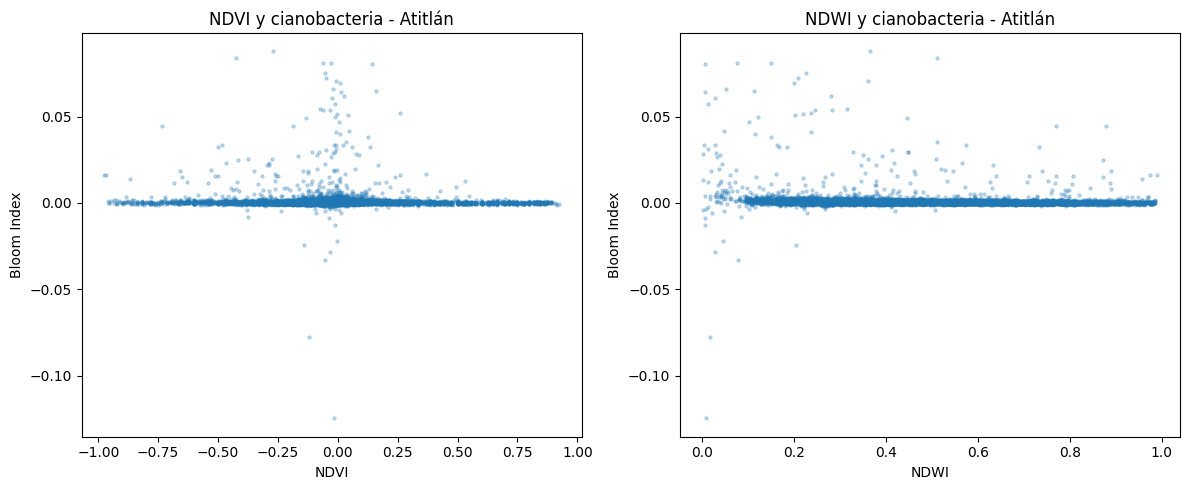

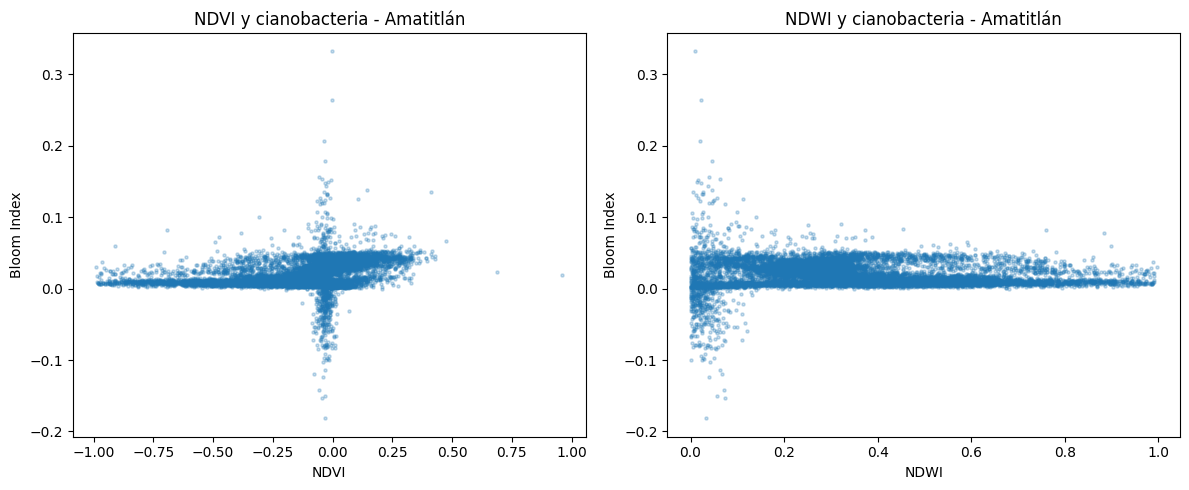

,lago,corr_cyano_ndvi,corr_cyano_ndwi
0,Atitlán,-0.025852,-0.081681
1,Amatitlán,0.287404,-0.083946


In [23]:
def obtener_muestra_correlacion(df, lago, muestra_por_fecha=15000):
    rng = np.random.default_rng(42)
    muestras = []

    datos = df[df["lago"] == lago].sort_values("fecha")

    for _, fila in datos.iterrows():
        indices = leer_y_calcular_indices(fila["archivo"])

        cyano = indices["cyano"]
        ndvi = indices["ndvi"]
        ndwi = indices["ndwi"]

        valido = (
            np.isfinite(cyano)
            & np.isfinite(ndvi)
            & np.isfinite(ndwi)
        )

        posiciones = np.flatnonzero(valido)

        if len(posiciones) > muestra_por_fecha:
            posiciones = rng.choice(
                posiciones,
                size=muestra_por_fecha,
                replace=False
            )

        muestras.append(pd.DataFrame({
            "cyano": cyano.ravel()[posiciones],
            "ndvi": ndvi.ravel()[posiciones],
            "ndwi": ndwi.ravel()[posiciones]
        }))

    return pd.concat(muestras, ignore_index=True)


def analizar_correlacion(df, lago):
    muestra = obtener_muestra_correlacion(df, lago)

    correlaciones = muestra[["cyano", "ndvi", "ndwi"]].corr()

    corr_ndvi = correlaciones.loc["cyano", "ndvi"]
    corr_ndwi = correlaciones.loc["cyano", "ndwi"]

    grafica = muestra.sample(
        min(12000, len(muestra)),
        random_state=42
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(
        grafica["ndvi"],
        grafica["cyano"],
        s=5,
        alpha=0.25
    )
    axes[0].set_title(f"NDVI y cianobacteria - {lago}")
    axes[0].set_xlabel("NDVI")
    axes[0].set_ylabel("Bloom Index")

    axes[1].scatter(
        grafica["ndwi"],
        grafica["cyano"],
        s=5,
        alpha=0.25
    )
    axes[1].set_title(f"NDWI y cianobacteria - {lago}")
    axes[1].set_xlabel("NDWI")
    axes[1].set_ylabel("Bloom Index")

    plt.tight_layout()

    salida = GRAFICOS_DIR / f"correlacion_indices_{nombre_seguro(lago)}.png"
    plt.savefig(salida, dpi=180, bbox_inches="tight")
    plt.show()

    return {
        "lago": lago,
        "corr_cyano_ndvi": corr_ndvi,
        "corr_cyano_ndwi": corr_ndwi
    }


corr_atitlan = analizar_correlacion(resultados, "Atitlán")
corr_amatitlan = analizar_correlacion(resultados, "Amatitlán")

tabla_correlaciones = pd.DataFrame([
    corr_atitlan,
    corr_amatitlan
])

tabla_correlaciones


## Hallazgos de correlación

En Atitlán la relación de cianobacteria con NDVI y NDWI es débil. Los valores quedan cerca de cero y no muestran una relación lineal clara.

En Amatitlán la relación con NDVI es positiva pero baja. La relación con NDWI sigue siendo débil y ligeramente negativa.

Esto indica que ninguno de los dos índices explica por sí solo la presencia de cianobacteria. Sirven como apoyo para entender el tipo de superficie y el comportamiento del agua, pero la floración también depende de otros factores.


# Ejercicio 7. Análisis y comparación de los lagos

Se comparan la intensidad, la frecuencia y la extensión de los valores altos para ver las diferencias entre Atitlán y Amatitlán.


In [24]:
comparacion_lagos = []

for lago in ["Atitlán", "Amatitlán"]:
    datos = resultados[resultados["lago"] == lago].copy()

    fila_pico = datos.loc[datos["cyano_promedio"].idxmax()]

    comparacion_lagos.append({
        "lago": lago,
        "cyano_promedio_periodo": datos["cyano_promedio"].mean(),
        "cyano_maximo": fila_pico["cyano_promedio"],
        "fecha_pico": fila_pico["fecha"].date(),
        "area_alta_promedio": datos["porcentaje_cyano_alto"].mean(),
        "area_alta_maxima": datos["porcentaje_cyano_alto"].max(),
        "fechas_area_mayor_1": int(
            (datos["porcentaje_cyano_alto"] > 1).sum()
        ),
        "fechas_area_mayor_5": int(
            (datos["porcentaje_cyano_alto"] > 5).sum()
        )
    })

tabla_comparacion = pd.DataFrame(comparacion_lagos)
tabla_comparacion


,lago,cyano_promedio_periodo,cyano_maximo,fecha_pico,area_alta_promedio,area_alta_maxima,fechas_area_mayor_1,fechas_area_mayor_5
0,Atitlán,0.000759,0.001289,2025-07-17,0.134876,0.245458,0,0
1,Amatitlán,0.018036,0.035372,2026-06-19,2.298540,9.255228,10,1


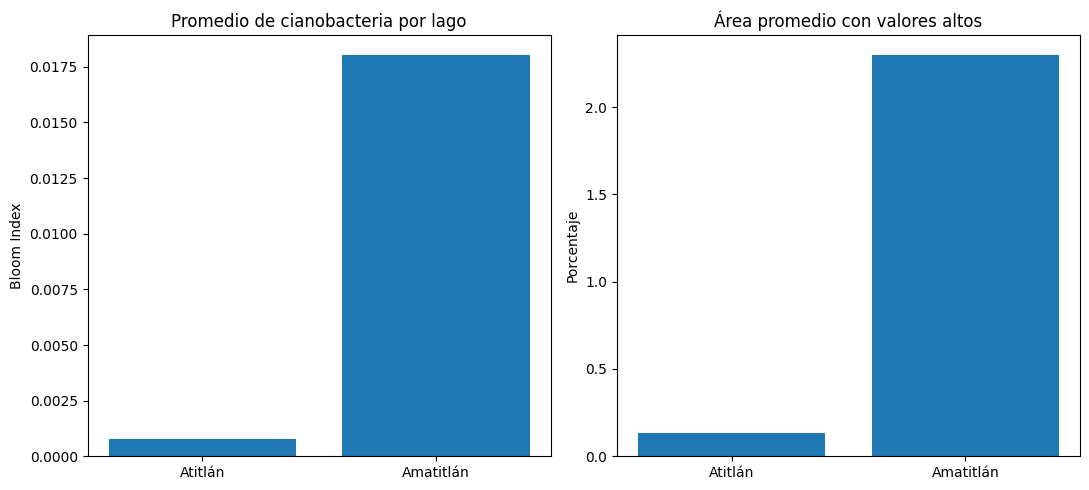

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].bar(
    tabla_comparacion["lago"],
    tabla_comparacion["cyano_promedio_periodo"]
)
axes[0].set_title("Promedio de cianobacteria por lago")
axes[0].set_ylabel("Bloom Index")

axes[1].bar(
    tabla_comparacion["lago"],
    tabla_comparacion["area_alta_promedio"]
)
axes[1].set_title("Área promedio con valores altos")
axes[1].set_ylabel("Porcentaje")

plt.tight_layout()

salida = GRAFICOS_DIR / "comparacion_general_lagos.png"
plt.savefig(salida, dpi=180, bbox_inches="tight")
plt.show()


## Comparación de resultados

Amatitlán presenta una señal de cianobacteria mucho mayor durante el período estudiado. Su promedio fue aproximadamente 24 veces mayor que el de Atitlán.

En Atitlán ninguna fecha superó uno por ciento del área de agua con valores altos. En Amatitlán esto pasó en diez de las once fechas y el valor más alto llegó a 9.26 por ciento el 19 de junio de 2026.

Atitlán tuvo su mayor promedio el 17 de julio de 2025 con un valor de 0.00129. Amatitlán tuvo su mayor promedio el 19 de junio de 2026 con un valor de 0.03537.

Los dos lagos pueden recibir nutrientes por escorrentía y aguas residuales. En Amatitlán también existe una presión urbana fuerte dentro de la cuenca. Esto puede ayudar a explicar por qué la señal observada es más frecuente e intensa. De todos modos, las imágenes satelitales no permiten asegurar una causa exacta por sí solas.


# Ejercicio 8. Análisis exploratorio adicional

En esta parte se revisa la extensión de los valores altos, la distribución entre fechas, los cambios espaciales y un posible patrón estacional.


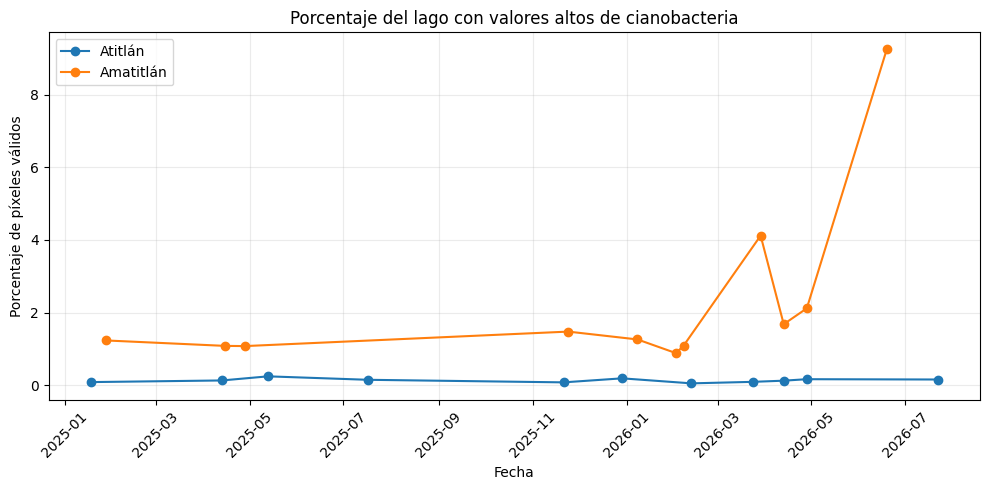

In [26]:
plt.figure(figsize=(10, 5))

for lago in ["Atitlán", "Amatitlán"]:
    datos = resultados[resultados["lago"] == lago].sort_values("fecha")

    plt.plot(
        datos["fecha"],
        datos["porcentaje_cyano_alto"],
        marker="o",
        label=lago
    )

plt.title("Porcentaje del lago con valores altos de cianobacteria")
plt.xlabel("Fecha")
plt.ylabel("Porcentaje de píxeles válidos")
plt.legend()
plt.grid(alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()

salida = GRAFICOS_DIR / "extension_floracion_lagos.png"
plt.savefig(salida, dpi=180, bbox_inches="tight")
plt.show()


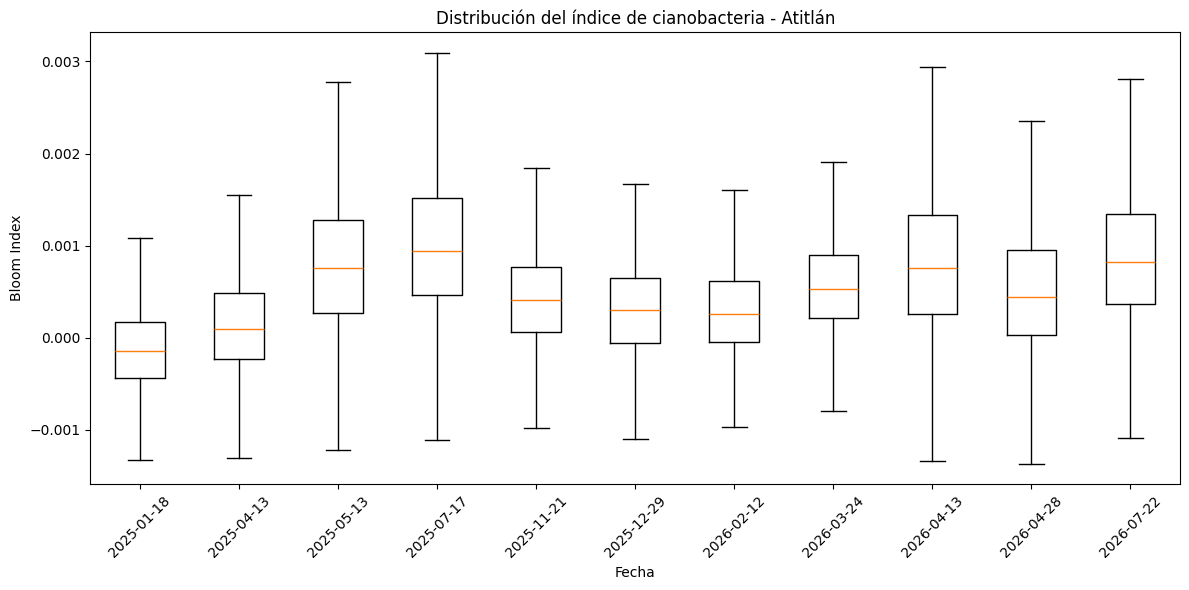

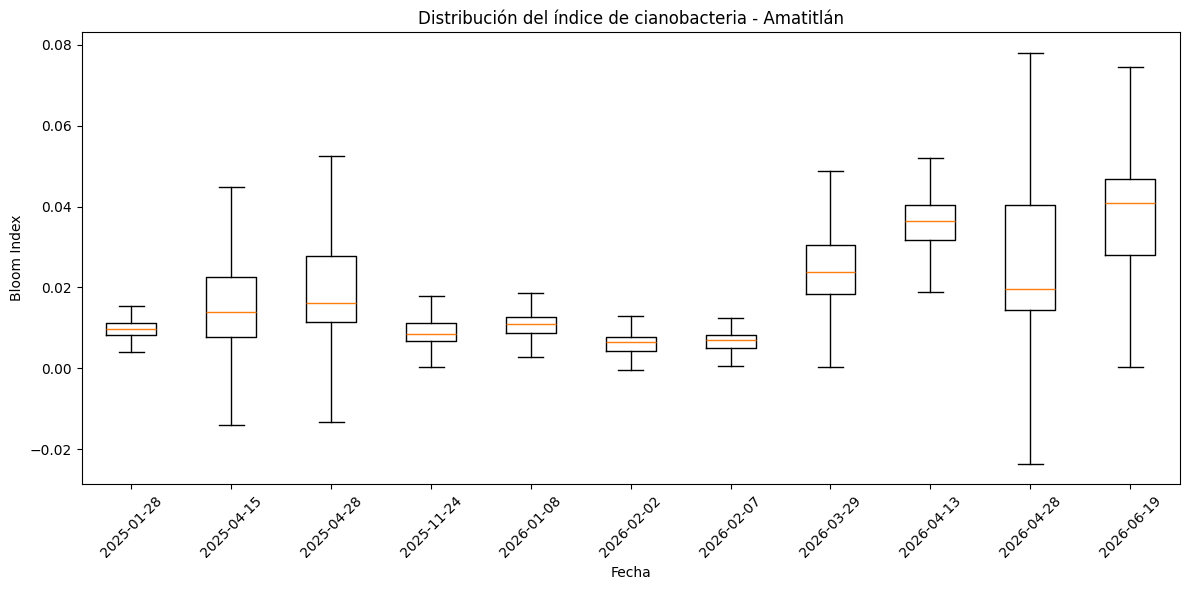

In [27]:
def boxplot_fechas(df, lago, muestra_por_fecha=4000):
    rng = np.random.default_rng(42)
    datos = df[df["lago"] == lago].sort_values("fecha")

    valores_box = []
    etiquetas = []

    for _, fila in datos.iterrows():
        cyano = leer_y_calcular_indices(fila["archivo"])["cyano"]
        valores = cyano[np.isfinite(cyano)]

        if len(valores) > muestra_por_fecha:
            valores = rng.choice(
                valores,
                size=muestra_por_fecha,
                replace=False
            )

        valores_box.append(valores)
        etiquetas.append(fila["fecha"].strftime("%Y-%m-%d"))

    plt.figure(figsize=(12, 6))
    plt.boxplot(
        valores_box,
        tick_labels=etiquetas,
        showfliers=False
    )
    plt.title(f"Distribución del índice de cianobacteria - {lago}")
    plt.xlabel("Fecha")
    plt.ylabel("Bloom Index")
    plt.xticks(rotation=45)
    plt.tight_layout()

    salida = GRAFICOS_DIR / f"boxplot_cyano_{nombre_seguro(lago)}.png"
    plt.savefig(salida, dpi=180, bbox_inches="tight")
    plt.show()


boxplot_fechas(resultados, "Atitlán")
boxplot_fechas(resultados, "Amatitlán")


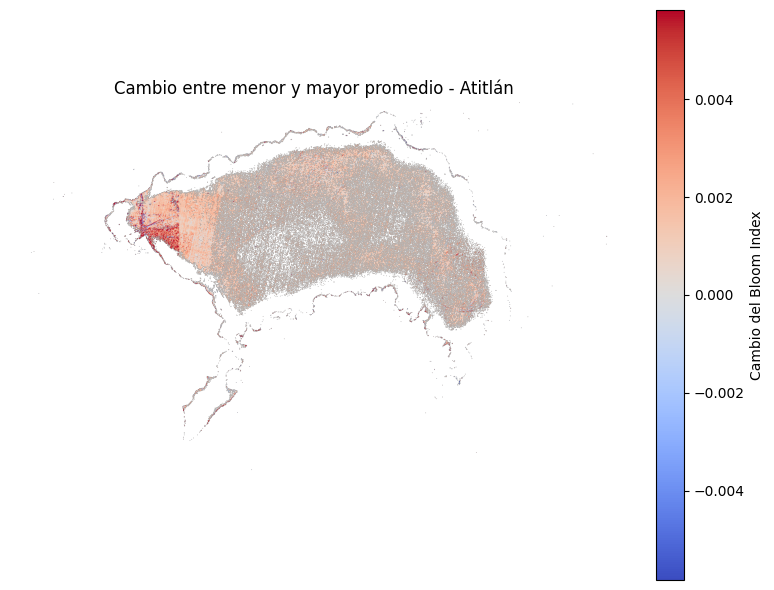

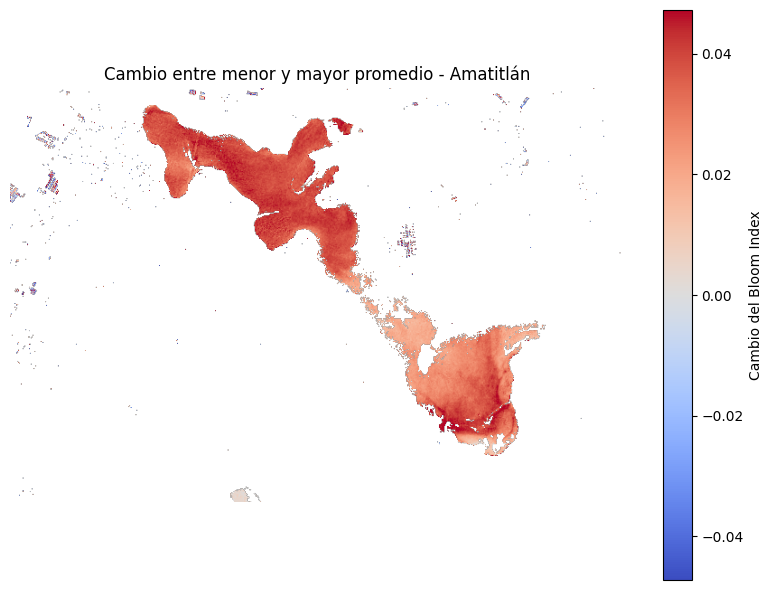

,lago,fecha_menor,fecha_mayor,porcentaje_aumento
0,Atitlán,2025-01-18,2025-07-17,89.766383
1,Amatitlán,2026-02-02,2026-06-19,97.864930


In [28]:
def mapa_diferencia(df, lago):
    datos = df[df["lago"] == lago].copy()

    fila_min = datos.loc[datos["cyano_promedio"].idxmin()]
    fila_max = datos.loc[datos["cyano_promedio"].idxmax()]

    cyano_min = leer_y_calcular_indices(fila_min["archivo"])["cyano"]
    cyano_max = leer_y_calcular_indices(fila_max["archivo"])["cyano"]

    diferencia = cyano_max - cyano_min

    valores = diferencia[np.isfinite(diferencia)]
    limite = np.nanpercentile(np.abs(valores), 98)

    plt.figure(figsize=(8, 6))
    imagen = plt.imshow(
        diferencia,
        vmin=-limite,
        vmax=limite,
        cmap="coolwarm"
    )
    plt.colorbar(imagen, label="Cambio del Bloom Index")
    plt.title(
        f"Cambio entre menor y mayor promedio - {lago}"
    )
    plt.axis("off")
    plt.tight_layout()

    salida = GRAFICOS_DIR / f"diferencia_cyano_{nombre_seguro(lago)}.png"
    plt.savefig(salida, dpi=180, bbox_inches="tight")
    plt.show()

    ambos = np.isfinite(cyano_min) & np.isfinite(cyano_max)

    return {
        "lago": lago,
        "fecha_menor": fila_min["fecha"].date(),
        "fecha_mayor": fila_max["fecha"].date(),
        "porcentaje_aumento": float(
            np.mean(diferencia[ambos] > 0) * 100
        )
    }


dif_atitlan = mapa_diferencia(resultados, "Atitlán")
dif_amatitlan = mapa_diferencia(resultados, "Amatitlán")

pd.DataFrame([
    dif_atitlan,
    dif_amatitlan
])


In [29]:
resultados_estacionales = resultados.copy()

resultados_estacionales["mes"] = resultados_estacionales["fecha"].dt.month

resultados_estacionales["temporada"] = np.where(
    resultados_estacionales["mes"].isin([5, 6, 7, 8, 9, 10]),
    "Lluviosa",
    "Seca"
)

resumen_estacional = (
    resultados_estacionales
    .groupby(["lago", "temporada"])
    .agg(
        cyano_promedio=("cyano_promedio", "mean"),
        area_alta_promedio=("porcentaje_cyano_alto", "mean"),
        fechas=("fecha", "count")
    )
    .reset_index()
)

resumen_estacional


,lago,temporada,cyano_promedio,area_alta_promedio,fechas
0,Amatitlán,Lluviosa,0.035372,9.255228,1
1,Amatitlán,Seca,0.016303,1.602871,10
2,Atitlán,Lluviosa,0.001213,0.184778,3
3,Atitlán,Seca,0.000589,0.116163,8


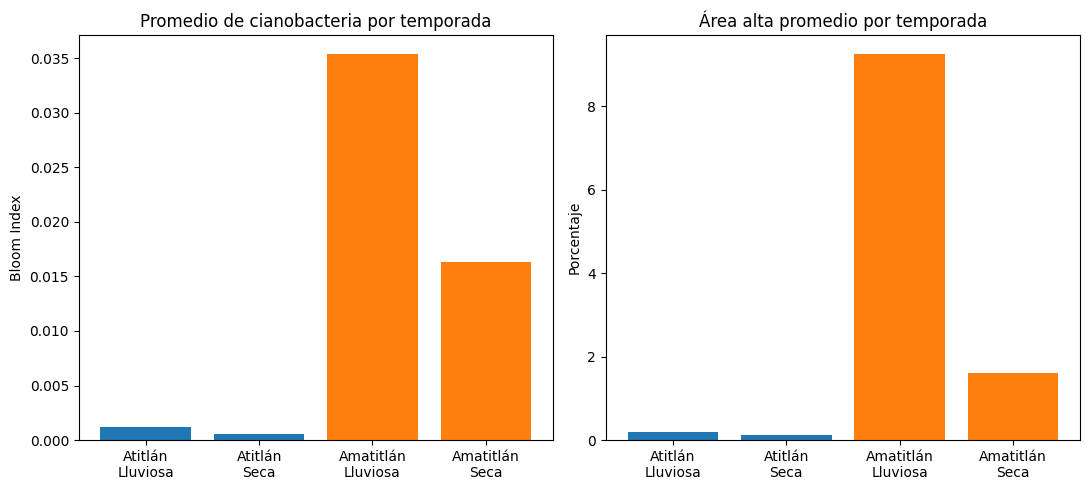

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for lago in ["Atitlán", "Amatitlán"]:
    datos = resumen_estacional[resumen_estacional["lago"] == lago]

    axes[0].bar(
        [f"{lago}\n{x}" for x in datos["temporada"]],
        datos["cyano_promedio"]
    )

    axes[1].bar(
        [f"{lago}\n{x}" for x in datos["temporada"]],
        datos["area_alta_promedio"]
    )

axes[0].set_title("Promedio de cianobacteria por temporada")
axes[0].set_ylabel("Bloom Index")

axes[1].set_title("Área alta promedio por temporada")
axes[1].set_ylabel("Porcentaje")

plt.tight_layout()

salida = GRAFICOS_DIR / "comparacion_estacional.png"
plt.savefig(salida, dpi=180, bbox_inches="tight")
plt.show()


## Hallazgos del análisis adicional

La extensión de los valores altos confirma la diferencia entre los lagos. Atitlán se mantiene por debajo de 0.25 por ciento en todas las fechas. Amatitlán llega a 9.26 por ciento y presenta un aumento claro durante 2026.

Los boxplots muestran que Amatitlán no solo tiene valores promedio mayores. También tiene una distribución más alta en varias fechas. El cambio entre la fecha mínima y la fecha pico fue positivo en casi 90 por ciento de los píxeles comparables de Atitlán y en casi 98 por ciento de Amatitlán.

En el análisis estacional los valores de época lluviosa son mayores en ambos lagos. Este resultado debe tomarse con cuidado porque las fechas no están distribuidas de forma pareja entre temporadas. En Amatitlán solo hay una fecha de época lluviosa dentro de la lista oficial.

Las zonas persistentes también son diferentes. En Atitlán aparecen pocos grupos de píxeles altos y se concentran más hacia el sur y el este. En Amatitlán la persistencia es mayor y se concentra principalmente hacia el noroeste.

En conjunto, Amatitlán muestra una proliferación más intensa, más extensa y más frecuente durante el período estudiado.


# Conclusiones

Los resultados muestran una diferencia clara entre los dos lagos. Atitlán tuvo valores bajos durante casi todo el período y las áreas con señal alta fueron pequeñas. Amatitlán tuvo valores mayores en casi todas las fechas y presentó los cambios más fuertes durante 2026.

El pico de Atitlán fue el 17 de julio de 2025. El pico de Amatitlán fue el 19 de junio de 2026. En esa fecha Amatitlán también tuvo la mayor extensión de valores altos con 9.26 por ciento del agua válida analizada.

La correlación con NDVI y NDWI no fue suficiente para explicar por sí sola los cambios de cianobacteria. Esto tiene sentido porque las floraciones también pueden responder a nutrientes, temperatura, lluvia, escorrentía y movimiento del agua.

Los mapas ayudaron a ver que las floraciones no aparecen igual en todo el lago. Hay zonas que repiten valores altos y otras que cambian entre fechas. Esto es importante porque un promedio general puede esconder áreas pequeñas con una señal más fuerte.

Con los resultados obtenidos, Amatitlán es el lago que presenta la condición más crítica dentro del período analizado.


# Fuentes usadas para la interpretación

Sentinel Hub Custom Scripts  
https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/maximum_peak_height_bloom_index/

Copernicus Data Space Ecosystem  
https://documentation.dataspace.copernicus.eu/APIs/openEO/Python_Client/Python.html

AMSCLAE  
https://www.amsclae.gob.gt/

AMSA  
https://amsa.gob.gt/
